In [ ]:
import pre_processamento

KeyboardInterrupt: 

In [ ]:
from pre_processamento import mass_train, mass_test, calc_train, calc_test
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#**Preparação dos Dados**

In [ ]:
# --- CONFIGURAÇÕES INICIAIS ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

# Função para simplificar as labels (opcional: transforma 'BENIGN_WITHOUT_CALLBACK' em 'BENIGN')
def simplify_pathology(df):
    df['pathology'] = df['pathology'].str.replace('BENIGN_WITHOUT_CALLBACK', 'BENIGN')
    return df

mass_train = simplify_pathology(mass_train)
mass_test = simplify_pathology(mass_test)

# --- DATA AUGMENTATION ---
# Importante para evitar overfitting em imagens médicas
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # Reservando 20% do treino para validação
)

test_datagen = ImageDataGenerator(rescale=1./255)

# --- GERADORES ---
# Usaremos as 'cropped_image_file_path' que costumam dar melhor resultado em classificação
train_generator = train_datagen.flow_from_dataframe(
    dataframe=mass_train,
    x_col='cropped_image_file_path',
    y_col='pathology',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_dataframe(
    dataframe=mass_train,
    x_col='cropped_image_file_path',
    y_col='pathology',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=mass_test,
    x_col='cropped_image_file_path',
    y_col='pathology',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1055 validated image filenames belonging to 2 classes.
Found 263 validated image filenames belonging to 2 classes.
Found 378 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras.regularizers import l2

# Carrega a ResNet50 sem a camada de cima (top)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congela os pesos do modelo base
# FINE-TUNING
base_model.trainable = False

for layer in base_model.layers[-50:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Adiciona novas camadas para o seu TCC
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
# O número de neurônios na saída deve ser igual ao número de classes (Benigno/Maligno)
# Acessa o dicionário de classes e conta quantos itens existem
num_classes = len(train_generator.class_indices)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compilação
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


In [ ]:
print(f"Total de imagens no treino: {train_generator.samples}")
print(f"Classes detectadas: {train_generator.class_indices}")

Total de imagens no treino: 1055
Classes detectadas: {'BENIGN': 0, 'MALIGNANT': 1}


In [ ]:
# CALCULAR CLASS WEIGHTS
weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Certifique-se de que o BATCH_SIZE está definido (padrão é 32)
BATCH_SIZE = 32

# Callbacks para otimizar o treino
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

# Treinamento
# O uso de steps_per_epoch é importante para garantir que o modelo veja todo o dataset
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5474 - auc: 0.5478 - loss: 0.7004 - precision: 0.5474 - recall: 0.5474 - val_accuracy: 0.4609 - val_auc: 0.5113 - val_loss: 0.7221 - val_precision: 0.4609 - val_recall: 0.4609 - learning_rate: 1.0000e-04
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 231ms/step - accuracy: 0.5625 - auc: 0.5972 - loss: 0.6751 - precision: 0.5625 - recall: 0.5625 - val_accuracy: 0.4609 - val_auc: 0.4771 - val_loss: 0.7222 - val_precision: 0.4609 - val_recall: 0.4609 - learning_rate: 1.0000e-04
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5728 - auc: 0.5910 - loss: 0.6799 - precision: 0.5728 - recall: 0.5728 - val_accuracy: 0.4609 - val_auc: 0.5244 - val_loss: 0.7292 - val_precision: 0.4609 - val_recall: 0.4609 - learning_rate: 1.0000e-04
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step - accuracy: 0.3750 - auc: 0.2930 - loss: 0.7864 - precision: 0.3750 - recall: 0.3750 - val_accuracy: 0.4492 - val_auc: 0.5162 - val_loss: 0.73

In [ ]:
print("\n--- Iniciando Fine-Tuning ---")

# Congela tudo primeiro
base_model.trainable = False

# Libera últimas camadas
for layer in base_model.layers[-50:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Recompila com LR menor
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights
)


   RESULTADOS FINAIS NO CONJUNTO DE TESTE
TEST LOSS: 0.6947
TEST COMPILE_METRICS: 0.4683

   RESUMO DA ÚLTIMA ÉPOCA DE TREINO
Época Final: 20
--------------------
Loss:       Treino: 0.6540 | Val: 0.6894
Acurácia:   Treino: 0.6250 | Val: 0.5078
AUC:        Treino: 0.6553 | Val: 0.5604
Precisão:   Treino: 0.6250 | Val: 0.5078
Recall:     Treino: 0.6250 | Val: 0.5078


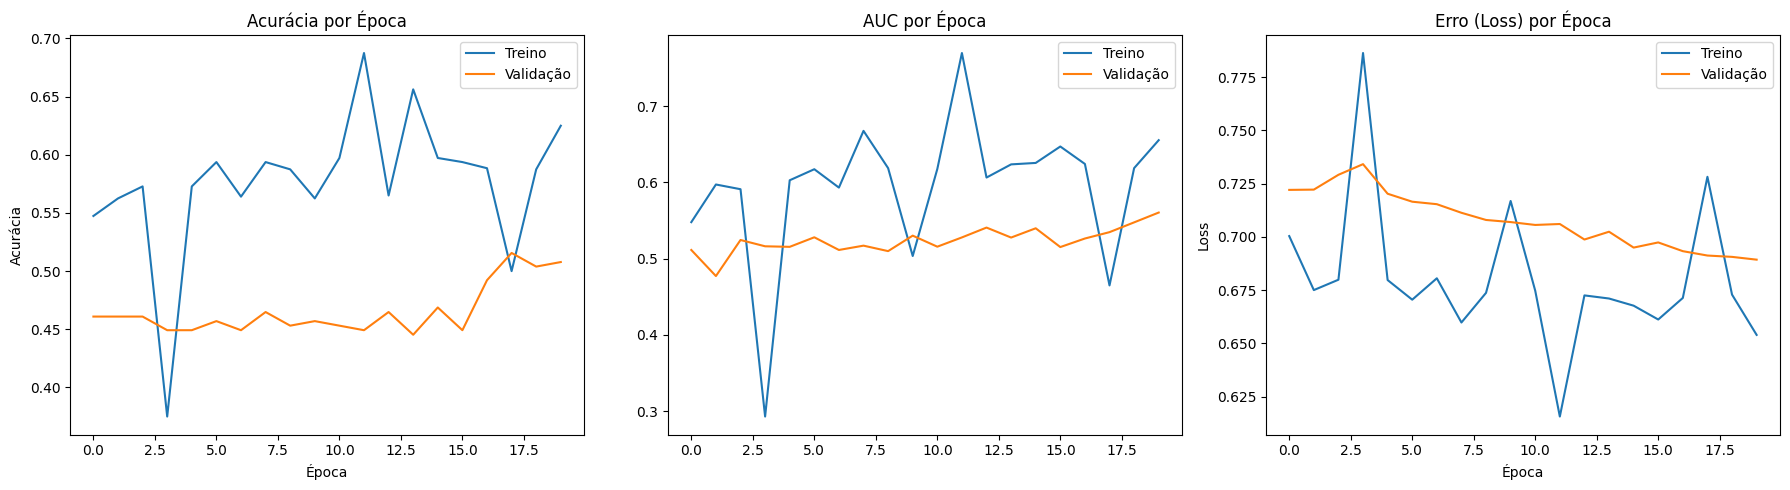

In [ ]:
import matplotlib.pyplot as plt

# 1. AVALIAÇÃO NO CONJUNTO DE TESTE
print("\n" + "="*40)
print("   RESULTADOS FINAIS NO CONJUNTO DE TESTE")
print("="*40)

results = model.evaluate(test_generator, verbose=0)

# O model.metrics_names contém os nomes que você definiu na compilação
for name, value in zip(model.metrics_names, results):
    print(f"TEST {name.upper()}: {value:.4f}")

# 2. MÉTRICAS DA ÚLTIMA ÉPOCA (TREINO E VALIDAÇÃO)
print("\n" + "="*40)
print("   RESUMO DA ÚLTIMA ÉPOCA DE TREINO")
print("="*40)

last_epoch = len(history.history['loss']) - 1
print(f"Época Final: {last_epoch + 1}")
print("-" * 20)
print(f"Loss:       Treino: {history.history['loss'][last_epoch]:.4f} | Val: {history.history['val_loss'][last_epoch]:.4f}")
print(f"Acurácia:   Treino: {history.history['accuracy'][last_epoch]:.4f} | Val: {history.history['val_accuracy'][last_epoch]:.4f}")
print(f"AUC:        Treino: {history.history['auc'][last_epoch]:.4f} | Val: {history.history['val_auc'][last_epoch]:.4f}")
print(f"Precisão:   Treino: {history.history['precision'][last_epoch]:.4f} | Val: {history.history['val_precision'][last_epoch]:.4f}")
print(f"Recall:     Treino: {history.history['recall'][last_epoch]:.4f} | Val: {history.history['val_recall'][last_epoch]:.4f}")
print("="*40)

# 3. PLOTAR GRÁFICOS (Mantendo sua lógica original)
plt.figure(figsize=(18, 5))

# Gráfico de Acurácia
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend()

# Gráfico de AUC
plt.subplot(1, 3, 2)
plt.plot(history.history['auc'], label='Treino')
plt.plot(history.history['val_auc'], label='Validação')
plt.title('AUC por Época')
plt.legend()

# Gráfico de Erro (Loss)
plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Erro (Loss) por Época')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()